In [3]:
import os
from utils import analyze_coco_distribution, visualize_bboxes, compare_metrics, generate_report

os.makedirs('artifacts/inference', exist_ok=True)
os.makedirs('artifacts/videos', exist_ok=True)
os.makedirs('artifacts/metrics', exist_ok=True)

ModuleNotFoundError: No module named 'matplotlib'

In [2]:
from utils import prepare_yolo_dataset
prepare_yolo_dataset('datasets/minecraft', 'yolo_datasets/minecraft')

Processing train split...
Successfully converted 2307 images to YOLO format in 'yolo_datasets/minecraft\train\labels'
Processing valid split...
Successfully converted 422 images to YOLO format in 'yolo_datasets/minecraft\valid\labels'
Processing test split...
Successfully converted 155 images to YOLO format in 'yolo_datasets/minecraft\test\labels'
Created data.yaml in yolo_datasets/minecraft


{'pig': 884, 'chicken': 835, 'cow': 661, 'zombie': 184, 'creeper': 177, 'skeleton': 177, 'spider': 170, 'turtle': 149, 'llama': 135, 'ghast': 127, 'fox': 111, 'frog': 111, 'goat': 102, 'sheep': 94, 'bee': 86, 'enderman': 22, 'wolf': 4, 'minecraft-mobs': 0}


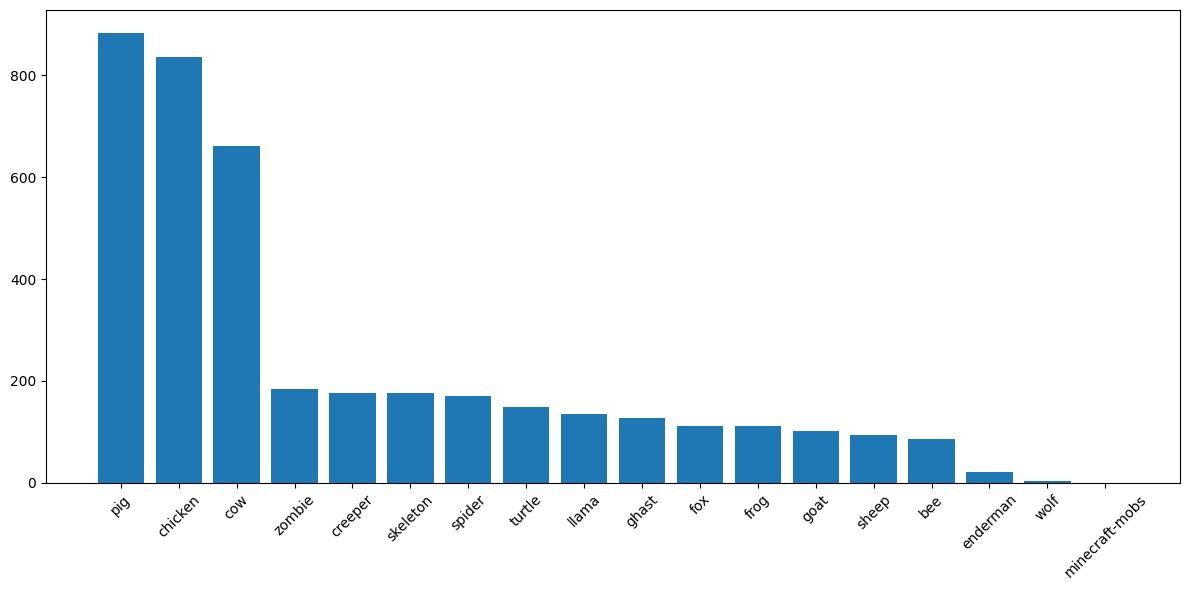

In [3]:
counts = analyze_coco_distribution('datasets/minecraft/train/annotations.json', 'artifacts/distribution.png')
print(counts)

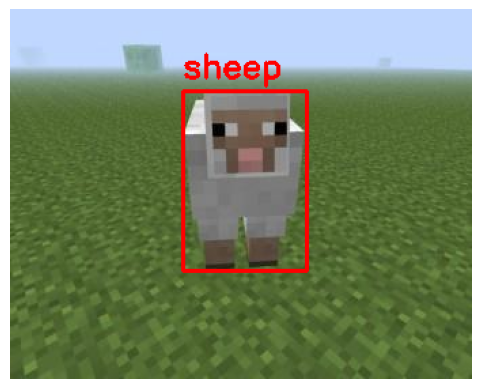

In [4]:
visualize_bboxes('datasets/minecraft/test/-5-_jpg.rf.bc815ec81b67584c880eb373c6de746a.jpg', 'datasets/minecraft/test/annotations.json', None, 'artifacts/inference/test_eda.jpg')


In [4]:
from mmdet.apis import DetInferencer

inferencer = DetInferencer(
    model='configs/fcos/fcos_minecraft.py',
    weights='checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth',
    device='cuda:0'
)

inferencer('datasets/minecraft/test/-5-_jpg.rf.bc815ec81b67584c880eb373c6de746a.jpg', 
           out_dir='artifacts/inference/', 
           no_save_pred=False)

Loads checkpoint by local backend from path: checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth
The model and loaded state dict do not match exactly

size mismatch for bbox_head.conv_cls.weight: copying a param with shape torch.Size([80, 256, 3, 3]) from checkpoint, the shape in current model is torch.Size([17, 256, 3, 3]).
size mismatch for bbox_head.conv_cls.bias: copying a param with shape torch.Size([80]) from checkpoint, the shape in current model is torch.Size([17]).
03/11 00:25:01 - mmengine - WARNING - Failed to search registry with scope "mmdet" in the "function" registry tree. As a workaround, the current "function" registry in "mmengine" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet" is a correct scope, or whether the registry is initialized.


Output()

c:\Users\igors\Projects\Computer-Vision\clean_venv\lib\site-packages\mmengine\visualization\visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '


c:\Users\igors\Projects\Computer-Vision\clean_venv\lib\site-packages\torch\functional.py:504: UserWarning: 
torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at
..\aten\src\ATen\native\TensorShape.cpp:3484.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]

{'predictions': [{'labels': [11,
    3,
    9,
    0,
    12,
    5,
    10,
    11,
    0,
    0,
    6,
    11,
    13,
    8,
    1,
    9,
    4,
    1,
    1,
    0,
    10,
    11,
    11,
    9,
    0,
    1,
    11,
    11,
    9,
    0,
    11,
    9,
    4,
    4,
    9,
    7,
    11,
    11,
    16,
    1,
    11,
    1,
    9,
    6,
    11,
    4,
    9,
    4,
    4,
    15,
    1,
    1,
    9,
    1,
    1,
    1,
    11,
    1,
    9,
    11,
    6,
    0,
    11,
    9,
    11,
    2,
    1,
    8,
    9,
    15,
    11,
    6,
    11,
    9,
    11,
    12,
    3,
    4,
    1,
    11,
    14,
    10,
    11,
    11,
    11,
    1,
    1,
    4,
    11,
    11,
    9,
    4,
    1,
    0,
    4,
    11,
    11,
    11,
    11,
    11],
   'scores': [0.5770682096481323,
    0.5200689435005188,
    0.5173045992851257,
    0.4967915713787079,
    0.48007529973983765,
    0.4788084328174591,
    0.47388434410095215,
    0.4523959457874298,
    0.4473963677883148,
    0.

In [ ]:
model = YOLO('yolov8s.pt')
model.train(
    data='yolo_datasets/minecraft/data.yaml', 
    epochs=12, 
    project='artifacts', 
    name='yolo',
    optimizer='AdamW',
    lr0=0.01,

    imgsz=512,      # Аналог Resize
    fliplr=0.5,     # Аналог RandomFlip
)



Ultralytics 8.4.21  Python-3.10.0 torch-2.0.0+cu118 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_datasets/minecraft/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=12, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

In [ ]:
!python tools/train.py configs/fcos/fcos_minecraft.py --work-dir artifacts/fcos

c:\Users\igors\Projects\Computer-Vision\clean_venv\lib\site-packages\torch\functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ..\aten\src\ATen\native\TensorShape.cpp:3484.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Traceback (most recent call last):
  File "c:\Users\igors\Projects\Computer-Vision\mmdetection\tools\train.py", line 121, in <module>
    main()
  File "c:\Users\igors\Projects\Computer-Vision\mmdetection\tools\train.py", line 117, in main
    runner.train()
  File "c:\Users\igors\Projects\Computer-Vision\clean_venv\lib\site-packages\mmengine\runner\runner.py", line 1777, in train
    model = self.train_loop.run()  # type: ignore
  File "c:\Users\igors\Projects\Computer-Vision\clean_venv\lib\site-packages\mmengine\runner\loops.py", line 98, in run
    self.run_epoch()
  File "c:\Users\igors\Projects\Computer-Vision\clean_venv\lib\site-packages\mmengin

03/11 01:42:53 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 643457164
    GPU 0: NVIDIA GeForce RTX 3060 Ti
    CUDA_HOME: None
    MSVC: Microsoft (R) C/C++ Optimizing Compiler Version 19.44.35219 for x64
    GCC: n/a
    PyTorch: 2.0.0+cu118
    PyTorch compiling details: PyTorch built with:
  - C++ Version: 199711
  - MSVC 193431937
  - Intel(R) Math Kernel Library Version 2020.0.2 Product Build 20200624 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 2019
  - LAPACK is enabled (usually provided by MKL)
  - CPU capability usage: AVX2
  - CUDA Runtime 11.8
  - NVCC architecture flags: -gencode;arch=compute_37,code=sm_37;-gencode;arch=compute_50,code=sm_50;-

In [14]:
from ultralytics import YOLO
yolo_trained = YOLO('artifacts/yolo/weights/best.pt')
yolo_trained.predict(source='datasets/minecraft/test/', save=True, project='artifacts/inference', name='yolo')
yolo_trained.predict(source='datasets/minecraft/video.mp4', save=True, project='artifacts/videos', name='yolo_inference')



image 1/155 c:\Users\igors\Projects\Computer-Vision\mmdetection\datasets\minecraft\test\-20-_jpg.rf.b6e634a136dcfb16a7a07cda96072ab8.jpg: 384x512 1 sheep, 5.5ms
image 2/155 c:\Users\igors\Projects\Computer-Vision\mmdetection\datasets\minecraft\test\-21-_jpg.rf.23982f2775c558c4c37a09bbaa2208b4.jpg: 288x512 (no detections), 6.7ms
image 3/155 c:\Users\igors\Projects\Computer-Vision\mmdetection\datasets\minecraft\test\-22-_jpg.rf.5e6e148f7c954ad021a5ef8eb50ed754.jpg: 256x512 1 pig, 5.9ms
image 4/155 c:\Users\igors\Projects\Computer-Vision\mmdetection\datasets\minecraft\test\-23-_jpg.rf.7d5cfa31d7e87f62f5578b045ffad4e6.jpg: 256x512 1 pig, 5.6ms
image 5/155 c:\Users\igors\Projects\Computer-Vision\mmdetection\datasets\minecraft\test\-24-_jpg.rf.075ddd9e73000ea2479d2c8c7473360e.jpg: 256x512 (no detections), 6.1ms
image 6/155 c:\Users\igors\Projects\Computer-Vision\mmdetection\datasets\minecraft\test\-25-_jpg.rf.a0dcd42afe0121abb9a8a1be6337c60c.jpg: 256x512 1 sheep, 6.2ms
image 7/155 c:\Users\

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'bee', 1: 'chicken', 2: 'cow', 3: 'creeper', 4: 'enderman', 5: 'fox', 6: 'frog', 7: 'ghast', 8: 'goat', 9: 'llama', 10: 'pig', 11: 'sheep', 12: 'skeleton', 13: 'spider', 14: 'turtle', 15: 'wolf', 16: 'zombie'}
 obb: None
 orig_img: array([[[75, 68, 33],
         [68, 61, 26],
         [56, 49, 14],
         ...,
         [11, 43, 22],
         [11, 43, 22],
         [11, 43, 22]],
 
        [[61, 54, 19],
         [61, 54, 19],
         [57, 50, 15],
         ...,
         [11, 43, 22],
         [11, 43, 22],
         [11, 43, 22]],
 
        [[82, 66, 32],
         [90, 74, 40],
         [91, 75, 41],
         ...,
         [11, 43, 22],
         [11, 43, 22],
         [11, 43, 22]],
 
        ...,
 
        [[29, 71, 40],
         [29, 71, 40],
         [29, 71, 40],
         ...,
         [34, 83, 46],
         [34, 83, 46],
        

In [16]:
!python demo/video_demo.py datasets/minecraft/video.mp4 configs/fcos/fcos_minecraft.py artifacts/fcos/latest.pth --out artifacts/videos/fcos_inference.mp4

Loads checkpoint by local backend from path: artifacts/fcos/latest.pth
[                                                  ] 0/756, elapsed: 0s, ETA:
[                                 ] 1/756, 1.3 task/s, elapsed: 1s, ETA:   601s
[                                 ] 2/756, 1.9 task/s, elapsed: 1s, ETA:   404s
[                                 ] 3/756, 2.2 task/s, elapsed: 1s, ETA:   341s
[                                 ] 4/756, 2.4 task/s, elapsed: 2s, ETA:   308s
[                                 ] 5/756, 2.6 task/s, elapsed: 2s, ETA:   287s
[                                 ] 6/756, 2.8 task/s, elapsed: 2s, ETA:   272s
[                                 ] 7/756, 2.9 task/s, elapsed: 2s, ETA:   261s
[                                 ] 8/756, 3.0 task/s, elapsed: 3s, ETA:   252s
[                                 ] 9/756, 3.0 task/s, elapsed: 3s, ETA:   247s
[                                ] 10/756, 3.1 task/s, elapsed: 3s, ETA:   242s
[                                ] 11/756, 3.1 task

c:\Users\igors\Projects\Computer-Vision\clean_venv\lib\site-packages\mmengine\visualization\visualizer.py:196: UserWarning: Failed to add <class 'mmengine.visualization.vis_backend.LocalVisBackend'>, please provide the `save_dir` argument.
  warnings.warn(f'Failed to add {vis_backend.__class__}, '
c:\Users\igors\Projects\Computer-Vision\clean_venv\lib\site-packages\torch\functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ..\aten\src\ATen\native\TensorShape.cpp:3484.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
c:\Users\igors\Projects\Computer-Vision\clean_venv\lib\site-packages\mmengine\visualization\visualizer.py:760: UserWarning: Warning: The bbox is out of bounds, the drawn bbox may not be in the image
  warnings.warn(
c:\Users\igors\Projects\Computer-Vision\clean_venv\lib\site-packages\mmengine\visualization\visualizer.py:831: UserWarning: Warning: The polygon

In [2]:
df_metrics = compare_metrics('artifacts/yolo/results.csv', 'artifacts/fcos/20260311_015948/vis_data/scalars.json', 'artifacts/metrics/metrics_comparison.csv')
print(df_metrics)

NameError: name 'compare_metrics' is not defined

In [3]:
generate_report("artifacts/distribution.png", "artifacts/metrics/metrics_comparison.csv", "artifacts/report.pdf")

Отчет успешно сгенерирован в: artifacts/report.pdf
